# Dataset Annotation for RESIDE-6K and O-HAZE

In this notebook we talk about:
- our chosen datasets
- number of classes
- train/test split
- sample images
- annotations


## Imports

In [130]:
from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Reproducibility
random.seed(42)

In [131]:
from pathlib import Path

BASE_DIR = Path(".")  # This points to the folder containing the notebook

DATASETS = {
    "RESIDE_test": {
        "haze": BASE_DIR / "test" / "hazy",
        "clean": BASE_DIR / "test" / "GT",
    },
    "RESIDE_train": {
        "haze": BASE_DIR / "train" / "hazy",
        "clean": BASE_DIR / "train" / "GT",
    },
    "OHAZE": {
        "haze": BASE_DIR / "O-HAZE" / "hazy",
        "clean": BASE_DIR / "O-HAZE" / "GT",
    }
}

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

## Image file information

Table with dataset name, class label and image path.

For our project, the class set up is hazy and clean. 

In [132]:
rows = []

for dataset_name, class_dict in DATASETS.items():
    for class_name, folder in class_dict.items():
        folder = Path(folder)
        if not folder.exists():
            print(f"Skipping missing folder: {folder}")
            continue

        for file in sorted(folder.rglob("*")):
            if file.is_file() and file.suffix.lower() in VALID_EXTENSIONS:
                rows.append({
                    "dataset": dataset_name,
                    "class": class_name,
                    "image_path": str(file)
                })

df = pd.DataFrame(rows)
print(f"Total images found: {len(df)}")
df.head()

Skipping missing folder: O-HAZE\hazy
Skipping missing folder: O-HAZE\GT
Total images found: 14000


,dataset,class,image_path
0,RESIDE_test,haze,test\hazy\0001_0.8_0.2.jpg
1,RESIDE_test,haze,test\hazy\0002_0.8_0.08.jpg
2,RESIDE_test,haze,test\hazy\0003_0.8_0.2.jpg
3,RESIDE_test,haze,test\hazy\0004_0.9_0.12.jpg
4,RESIDE_test,haze,test\hazy\0006_0.85_0.08.jpg


## Basic dataset summary

For understanding the data:

In [133]:
if len(df) == 0:
    print("No images found yet. Check your folder paths above.")
else:
    print("Images per dataset:")
    display(df["dataset"].value_counts().rename_axis("dataset").reset_index(name="count"))

    print("Images per class:")
    display(df["class"].value_counts().rename_axis("class").reset_index(name="count"))

    print("Images per dataset and class:")
    display(df.groupby(["dataset", "class"]).size().reset_index(name="count"))

Images per dataset:


,dataset,count
0,RESIDE_train,12000
1,RESIDE_test,2000


Images per class:


,class,count
0,haze,7000
1,clean,7000


Images per dataset and class:


,dataset,class,count
0,RESIDE_test,clean,1000
1,RESIDE_test,haze,1000
2,RESIDE_train,clean,6000
3,RESIDE_train,haze,6000


## Number of classes


In [134]:
if len(df) == 0:
    print("No data available.")
else:
    classes = sorted(df["class"].unique().tolist())
    num_classes = len(classes)
    print("Classes:", classes)
    print("Number of classes:", num_classes)

Classes: ['clean', 'haze']
Number of classes: 2


## Train/test split

We're using a simple train test split here:
- 80% train
- 20% test

It is done **within each class** so the split stays balanced.

In [135]:
TRAIN_RATIO = 0.8

split_rows = []

if len(df) == 0:
    print("No data available.")
else:
    # for class_name, group in df.groupby("class"):
    for (dataset_name, class_name), group in df.groupby(["dataset", "class"]):
        group = group.sample(frac=1, random_state=42).reset_index(drop=True)
        split_index = int(len(group) * TRAIN_RATIO)

        train_group = group.iloc[:split_index].copy()
        test_group = group.iloc[split_index:].copy()

        train_group["split"] = "train"
        test_group["split"] = "test"

        split_rows.append(train_group)
        split_rows.append(test_group)

    split_df = pd.concat(split_rows, ignore_index=True)
    display(split_df.head())

,dataset,class,image_path,split
0,RESIDE_test,clean,test\GT\1415_7.png,train
1,RESIDE_test,clean,test\GT\1437_3.png,train
2,RESIDE_test,clean,test\GT\1437_6.png,train
3,RESIDE_test,clean,test\GT\1429_6.png,train
4,RESIDE_test,clean,test\GT\1404_7.png,train


## Train/test summary

In [136]:
if 'split_df' not in globals():
    print("Split has not been created.")
else:
    print("Overall split counts:")
    display(split_df["split"].value_counts().rename_axis("split").reset_index(name="count"))

    print("Split counts by class:")
    display(split_df.groupby(["class", "split"]).size().reset_index(name="count"))

    print("Split counts by dataset:")
    display(split_df.groupby(["dataset", "split"]).size().reset_index(name="count"))

Overall split counts:


,split,count
0,train,11200
1,test,2800


Split counts by class:


,class,split,count
0,clean,test,1400
1,clean,train,5600
2,haze,test,1400
3,haze,train,5600


Split counts by dataset:


,dataset,split,count
0,RESIDE_test,test,400
1,RESIDE_test,train,1600
2,RESIDE_train,test,2400
3,RESIDE_train,train,9600


In [137]:
if 'split_df' not in globals():
    print("No split data to save.")
else:
    output_path = Path("dataset_index.csv")
    split_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path.resolve()}")

Saved: C:\Users\Haider Ali\OneDrive\Desktop\DL_Proj\dataset_index.csv


## Sample images

Displaying a few sample images from each class to understand the images we're working with:

Sample images for class: clean


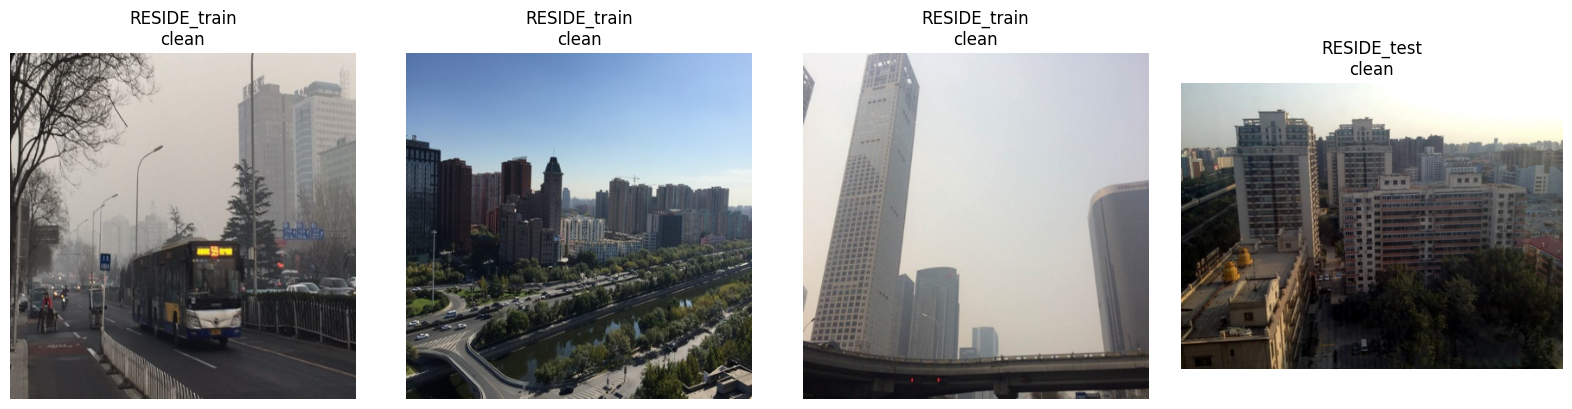

Sample images for class: haze


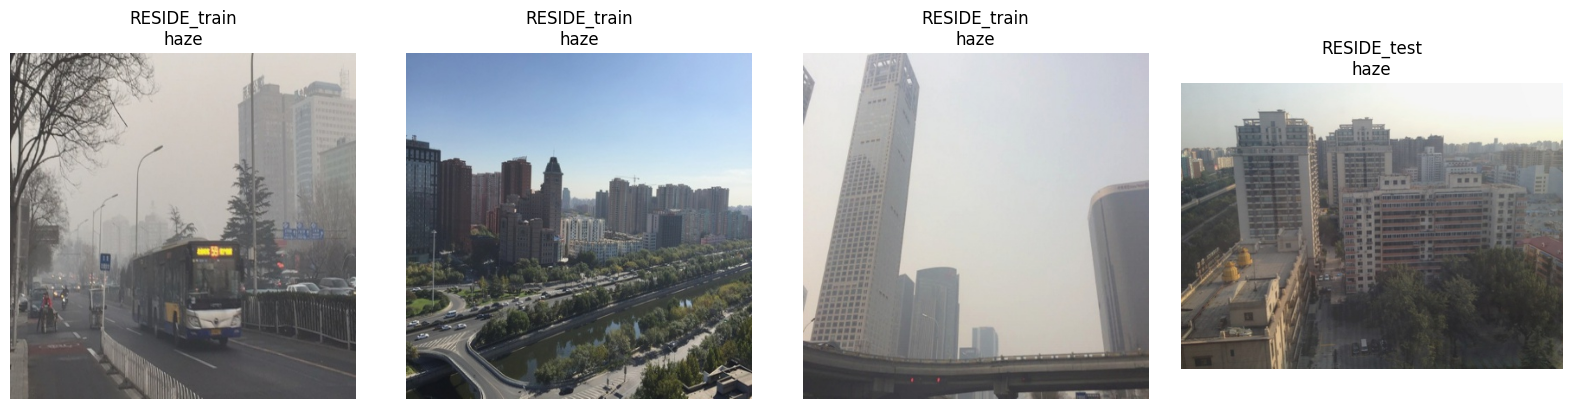

In [138]:
def show_sample_images(dataframe, class_name, n=4):
    subset = dataframe[dataframe["class"] == class_name]
    if len(subset) == 0:
        print(f"No images found for class: {class_name}")
        return

    sample_n = min(n, len(subset))
    samples = subset.sample(sample_n, random_state=42)

    fig, axes = plt.subplots(1, sample_n, figsize=(4 * sample_n, 4))
    if sample_n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{row['dataset']}\n{row['class']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if len(df) == 0:
    print("No images found.")
else:
    for class_name in sorted(df["class"].unique()):
        print(f"Sample images for class: {class_name}")
        show_sample_images(df, class_name, n=4)

## 10. Annotation description

For this project, a **basic annotation** is enough if you are using pre-existing datasets.

That means each image is documented with:
- dataset name
- class label
- image path
- train/test split

This is stored in `dataset_index.csv`.

If you are only using RESIDE and O-HAZE, your annotations can remain **image-level annotations** rather than bounding boxes or masks.

In [139]:
if 'split_df' not in globals():
    print("No data available.")
else:
    annotation_preview = split_df[["dataset", "class", "image_path", "split"]].head(10)
    display(annotation_preview)

,dataset,class,image_path,split
0,RESIDE_test,clean,test\GT\1415_7.png,train
1,RESIDE_test,clean,test\GT\1437_3.png,train
2,RESIDE_test,clean,test\GT\1437_6.png,train
3,RESIDE_test,clean,test\GT\1429_6.png,train
4,RESIDE_test,clean,test\GT\1404_7.png,train
5,RESIDE_test,clean,test\GT\1431_4.png,train
6,RESIDE_test,clean,test\GT\1426_2.png,train
7,RESIDE_test,clean,test\GT\1414_9.png,train
8,RESIDE_test,clean,test\GT\1449_5.png,train
9,RESIDE_test,clean,test\GT\0163_0.95_0.08.jpg,train


## 11. Optional note on custom annotation

This project mainly uses pre-existing datasets, so no heavy manual annotation was required. A basic image-level annotation file was created containing dataset source, class label, file path, and train/test split. This was sufficient for organizing and understanding the data for the project.

If you later add smoke images or mixed haze-smoke images, you can update the annotation file with additional labels.

## 12. Final submission summary

You can copy this into your report or presentation after running the notebook.

- **Datasets used:** RESIDE and O-HAZE  
- **Classes used:** based on folder labels shown above  
- **Number of classes:** computed in Section 5  
- **Train/test split:** 80/20 random split within each class  
- **Sample images:** shown in Section 9  
- **Annotations:** basic image-level annotation saved in `dataset_index.csv`  
- **Custom annotation:** minimal, since these are pre-existing datasets